# Chapter 9 (extra) — Current reversal and successive electron transfers

This companion to `09_chronopotentiometry.ipynb` develops two galvanostatic
chronopotentiometry experiments whose **transition-time ratios** are clean,
kinetics-independent diagnostics:

1. **Current reversal.** Reverse the current at $\tau_1$; a second transition
   appears at $\tau_2=\tfrac13\tau_1$ (re-oxidation of the diffusing product).
2. **Successive electron transfers / two-component system.** A second couple
   $\mathrm{O_2}+n_2 e^-\!\rightleftharpoons\mathrm{R_2}$ (an EE mechanism or a
   second independent species) whose formal potential is well separated from the
   first. After the first transition the applied current is partitioned between
   the continuing flux of $\mathrm{O_1}$ and the new flux of $\mathrm{O_2}$, and
   the second transition occurs at $\tau_2=3\tau_1$ (equal concentrations, equal
   $n$).

Both are ports of Honeychurch's `ExplicitChronoPot` / `ExplicitChronoPot2`
notebooks (`solveFor`, `solveForSecond`, `stopBack`/`stopFor2`), re-implemented
idiomatically in vectorised numpy. The diffusion engine and the
current-controlled (flux) surface boundary are exactly those of the main chapter
notebook; only the *number of tracked species* and the *boundary bookkeeping*
change.

> **Why these ratios.** Both $\tau_2/\tau_1$ values follow from the
> Laplace-transform surface-concentration solutions and are completely
> independent of the electrode kinetics; they are the strongest possible
> analytic targets for validating a galvanostatic FD code.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

np.set_printoptions(precision=5, suppress=True)


## 1. The two transition-time ratios (analytic)

**Current reversal.** Reversing the current at $t_1=\tau_1$ makes the surface
concentration of the product R proportional to $t^{1/2}-2(t-\tau_1)^{1/2}$ for
$t>\tau_1$. It reaches zero at $t=\tau_1+\tau_2$ when
$\sqrt{\tau_1+\tau_2}=2\sqrt{\tau_2}$, i.e. $\tau_1+\tau_2=4\tau_2$, hence

$$\boxed{\;\tau_2=\tfrac13\tau_1\;}\qquad(\text{current reversal}).$$

**Successive electron transfers.** With two couples and the current split as
$i=i_1+i_2$, the Laplace-domain surface condition for $t>\tau_1$ (where the
$\mathrm{O_1}$ surface concentration is pinned at zero but $\mathrm{O_1}$ keeps
diffusing in) gives, for equal diffusion coefficients and equal $n$, a second
transition obeying $i\,(\tau_1+\tau_2)^{1/2}=2\,i\,\tau_1^{1/2}$ for the combined
process, which combined with the Sand relation for each step yields

$$\boxed{\;\tau_2=3\,\tau_1\;}\qquad(\text{equal }c,\;n_1=n_2).$$

So the second transition of a two-component system is **three times longer**
than the first, the mirror image of the reversal result. We now reproduce both
ratios from the FD simulation.

In [2]:
import sympy as sp

# Symbolic confirmation of both transition-time ratios, independent of any
# floating-point code below (genuine symbolic derivation -> sympy).
t, tau1, tau2 = sp.symbols("t tau1 tau2", positive=True)

# (a) current reversal: surface R(t) ~ sqrt(t) - 2 sqrt(t - tau1) = 0 at t = tau1+tau2
revsol = sp.solve(sp.sqrt(tau1 + tau2) - 2 * sp.sqrt(tau2), tau2)
print("current reversal  tau2 =", revsol[0], " = tau1/3 ?", sp.simplify(revsol[0] - tau1/3) == 0)

# (b) successive transfers: combined Sand gives sqrt(tau1+tau2) = 2 sqrt(tau1)
eesol = sp.solve(sp.sqrt(tau1 + tau2) - 2 * sp.sqrt(tau1), tau2)
print("successive ET     tau2 =", eesol[0], " = 3 tau1 ?", sp.simplify(eesol[0] - 3*tau1) == 0)

assert sp.simplify(revsol[0] - tau1/3) == 0
assert sp.simplify(eesol[0] - 3*tau1) == 0
print("\nPASS: symbolic transition-time ratios confirmed (tau2=tau1/3 and tau2=3 tau1)")


current reversal  tau2 = tau1/3  = tau1/3 ? True
successive ET     tau2 = 3*tau1  = 3 tau1 ? True

PASS: symbolic transition-time ratios confirmed (tau2=tau1/3 and tau2=3 tau1)


## 2. Shared finite-difference engine

A single explicit diffusion step advances any number of species fields on the
same grid. Each species $c_j$ updates by the three-point stencil
$c_j^{k+1}=D_M c_{j-1}+(1-2D_M)c_j+D_M c_{j+1}$ ($D_M\le\tfrac12$). The surface
node of each species is then set by a **current-controlled** 3-point flux
condition; the outer node is clamped to its bulk value. We keep the grid wide
enough that the diffusion layer never reaches the outer boundary
($m=1+\lceil 6\sqrt{D_M (n-1)}\rceil$, as in Honeychurch).

In [3]:
def diffuse(c, DM):
    """One explicit interior diffusion step for a 1-D species field.

    Updates interior nodes by the three-point stencil and leaves the two end
    nodes for the caller to set (surface flux BC / bulk clamp).
    """
    new = c.copy()
    new[1:-1] = DM * c[:-2] + (1.0 - 2.0 * DM) * c[1:-1] + DM * c[2:]
    return new


def grid_size(n, DM):
    """Honeychurch's spatial node count m = 1 + ceil(6 sqrt(DM (n-1)))."""
    return 1 + int(np.ceil(6.0 * np.sqrt(DM * (n - 1))))


def i_dim_from_current(i, n, DM):
    """Dimensionless flux current iDim = 2 i / sqrt(DM (n-1))."""
    return (2.0 * i) / np.sqrt(DM * (n - 1))


## 3. Current reversal: recovering $\tau_2=\tau_1/3$

Run the forward galvanostatic step (reduction of $\mathrm{O}$) until the surface
$\mathrm{O}$ is depleted ($\tau_1$), flip the sign of the current, and continue
the *same* field until the surface $\mathrm{R}$ is depleted ($\tau_2$). The
surface nodes use the two-species flux conditions
$c_{O,1}=\tfrac13(i_\text{dim}+4c_{O,2}-c_{O,3})$ and
$c_{R,1}=\tfrac13(-i_\text{dim}+4c_{R,2}-c_{R,3})$.

In [4]:
def simulate_reversal(i=-0.9, n=401, DM=0.35):
    """Two-species current-reversal chronopotentiometry.

    Returns (n1, n2): step counts of the forward and reversal segments
    (discrete tau_1, tau_2).
    """
    m = grid_size(n, DM)
    iDim = i_dim_from_current(i, n, DM)
    cO, cR = np.ones(m), np.zeros(m)

    def advance(cO, cR, iDim):
        cO, cR = diffuse(cO, DM), diffuse(cR, DM)
        cO[0] = (iDim + 4.0 * cO[1] - cO[2]) / 3.0
        cR[0] = (-iDim + 4.0 * cR[1] - cR[2]) / 3.0
        cO[-1], cR[-1] = 1.0, 0.0
        return cO, cR

    n1 = 0
    for _ in range(n - 1):
        cO, cR = advance(cO, cR, iDim)
        if cO[0] < 0.0:
            break
        n1 += 1

    iDim = -iDim
    n2 = 0
    for _ in range(4 * (n - 1)):
        cO, cR = advance(cO, cR, iDim)
        if cR[0] < 0.0:
            break
        n2 += 1
    return n1, n2


n = 401
n1, n2 = simulate_reversal(-0.9, n=n)
print(f"forward  tau_1 = {n1} steps")
print(f"reversal tau_2 = {n2} steps")
print(f"ratio tau_2/tau_1 = {n2/n1:.4f}   target 1/3 = {1/3:.4f}")


forward  tau_1 = 387 steps
reversal tau_2 = 129 steps
ratio tau_2/tau_1 = 0.3333   target 1/3 = 0.3333


### Validation: $\tau_2=\tau_1/3$

**Strategy (Spec §1, tier 1, independent closed-form check).** Assert the
discrete ratio matches the exact analytic value $1/3$ to within the grid
resolution (one step out of $\sim n_1/3$).

In [5]:
ratio = n2 / n1
target = 1.0 / 3.0
rel = abs(ratio - target) / target
print(f"tau_2/tau_1 = {ratio:.4f}   target {target:.4f}   rel.err {rel:.3%}")
assert rel < 0.03, f"reversal ratio off by {rel:.3%}"
print("PASS: current-reversal transition tau_2 = tau_1/3")


tau_2/tau_1 = 0.3333   target 0.3333   rel.err 0.000%
PASS: current-reversal transition tau_2 = tau_1/3


## 4. Successive electron transfers / two-component system: $\tau_2=3\tau_1$

Now four fields: $\mathrm{O_1},\mathrm{R_1},\mathrm{O_2},\mathrm{R_2}$, all on
the same grid. The second couple's formal potential is far enough negative that
$\mathrm{O_2}$ is untouched until after $\tau_1$.

**Segment 1 ($t<\tau_1$).** Identical to the single-couple run: the current
reduces $\mathrm{O_1}$ only. Surface conditions
$c_{O_1,1}=\tfrac13(i_\text{dim}+4c_{O_1,2}-c_{O_1,3})$,
$c_{R_1,1}=\tfrac13(-i_\text{dim}+4c_{R_1,2}-c_{R_1,3})$; $\mathrm{O_2},\mathrm{R_2}$
just diffuse (bulk-clamped, untouched). Stops when surface $\mathrm{O_1}=0$.

**Segment 2 ($\tau_1<t<\tau_2$).** Now the surface $\mathrm{O_1}$ is pinned at
$0$ and surface $\mathrm{R_1}$ at $1$ (all of $\mathrm{O_1}$ that arrives is
immediately reduced). $\mathrm{O_1}$ nonetheless **keeps diffusing in**, carrying
part of the current; the remainder reduces $\mathrm{O_2}$. The total current is
partitioned, giving the surface conditions Honeychurch derives,

$$c_{O_2,1}=\tfrac13\big(i_\text{dim}+4c_{O_1,2}-c_{O_1,3}+4c_{O_2,2}-c_{O_2,3}\big),$$
$$c_{R_2,1}=\tfrac13\big(-i_\text{dim}-3+4c_{R_1,2}-c_{R_1,3}+4c_{R_2,2}-c_{R_2,3}\big),$$

(the $-3$ term comes from $c_{R_1,1}=1$). Stops when surface $\mathrm{O_2}=0$
(the second transition).

In [6]:
def simulate_two_component(i=-0.9, n=401, DM=0.35):
    """Two-component / EE galvanostatic chronopotentiometry.

    Tracks O1, R1, O2, R2 on a shared grid. Returns (n1, n2): step counts of the
    first (O1 reduction) and second (O2 reduction) transitions.

    Port of Honeychurch's ``solveFor`` / ``solveForSecond`` (4-species version),
    with the second-segment boundary partitioning the current between the
    continuing O1 flux and the new O2 flux.
    """
    m = grid_size(n, DM)
    iDim = i_dim_from_current(i, n, DM)
    O1, R1 = np.ones(m), np.zeros(m)
    O2, R2 = np.ones(m), np.zeros(m)

    # --- segment 1: reduce O1 only ---
    n1 = 0
    for _ in range(n - 1):
        O1, R1, O2, R2 = diffuse(O1, DM), diffuse(R1, DM), diffuse(O2, DM), diffuse(R2, DM)
        O1[0] = (iDim + 4.0 * O1[1] - O1[2]) / 3.0
        R1[0] = (-iDim + 4.0 * R1[1] - R1[2]) / 3.0
        O2[0], R2[0] = 1.0, 0.0          # second couple untouched
        for arr, bulk in ((O1, 1.0), (R1, 0.0), (O2, 1.0), (R2, 0.0)):
            arr[-1] = bulk
        if O1[0] < 0.0:
            break
        n1 += 1

    # at tau_1 the O1 surface is exhausted; pin it and saturate R1 surface
    O1[0], R1[0] = 0.0, 1.0

    # --- segment 2: current partitioned between O1 (diffusion-limited) and O2 ---
    n2 = 0
    for _ in range(4 * (n - 1)):
        O1, R1, O2, R2 = diffuse(O1, DM), diffuse(R1, DM), diffuse(O2, DM), diffuse(R2, DM)
        # surfaces of couple 1 are pinned (O1 fully reduced at the surface)
        O1[0], R1[0] = 0.0, 1.0
        # couple-2 surface from the partitioned current (Honeychurch solveForSecond)
        O2[0] = (iDim + 4.0 * O1[1] - O1[2] + 4.0 * O2[1] - O2[2]) / 3.0
        R2[0] = (-iDim - 3.0 + 4.0 * R1[1] - R1[2] + 4.0 * R2[1] - R2[2]) / 3.0
        for arr, bulk in ((O1, 1.0), (R1, 0.0), (O2, 1.0), (R2, 0.0)):
            arr[-1] = bulk
        if O2[0] < 0.0:
            break
        n2 += 1
    return n1, n2


n1c, n2c = simulate_two_component(-0.9, n=n)
print(f"first  transition tau_1 = {n1c} steps")
print(f"second transition tau_2 = {n2c} steps")
print(f"ratio tau_2/tau_1 = {n2c/n1c:.4f}   target 3 = 3.0000")


first  transition tau_1 = 387 steps
second transition tau_2 = 1163 steps
ratio tau_2/tau_1 = 3.0052   target 3 = 3.0000


### Validation: $\tau_2=3\tau_1$

**Strategy (Spec §1, tier 1, independent closed-form check)** plus
**tier 3 (convergence)**. The exact analytic ratio is $\tau_2/\tau_1=3$. The
discrete ratio approaches $3$ as the grid is refined (Honeychurch notes the
ratio improves with larger $n$); we therefore (a) assert the ratio is within a
few percent of $3$ at the working grid, and (b) assert it **converges toward 3**
as $n$ increases (the refinement error shrinks).

We also reduce the two-component code to a **known limit**: if the second couple
is absent (its bulk concentration set to zero so $\mathrm{O_2}$ can never carry
current), the simulation must terminate at the single Sand transition with no
extended second segment.

In [7]:
# (a) ratio near 3 at the working grid
ratio = n2c / n1c
print(f"n={n}:  tau_2/tau_1 = {ratio:.4f}  (target 3, rel.err {abs(ratio-3)/3:.2%})")
assert abs(ratio - 3.0) / 3.0 < 0.05, f"two-component ratio off by {abs(ratio-3)/3:.2%}"

# (b) convergence: refinement error to 3 shrinks as n grows
errs = []
for nn in (201, 401, 801):
    a, b = simulate_two_component(-0.9, n=nn)
    r = b / a
    errs.append(abs(r - 3.0) / 3.0)
    print(f"n={nn:4d}:  tau_2/tau_1 = {r:.4f}   rel.err to 3 = {errs[-1]:.3%}")
assert errs[-1] < errs[0], "refinement did not reduce the error toward 3"
print("\nPASS: tau_2 = 3 tau_1, and the ratio converges to 3 under grid refinement")


n=401:  tau_2/tau_1 = 3.0052  (target 3, rel.err 0.17%)
n= 201:  tau_2/tau_1 = 3.0104   rel.err to 3 = 0.345%


n= 401:  tau_2/tau_1 = 3.0052   rel.err to 3 = 0.172%

n= 801:  tau_2/tau_1 = 3.0013   rel.err to 3 = 0.043%

PASS: tau_2 = 3 tau_1, and the ratio converges to 3 under grid refinement


In [8]:
# Reduction-to-known-limit: no second couple -> only the single Sand transition.
def simulate_no_second_couple(i=-0.9, n=401, DM=0.35):
    """Two-component code with O2 absent (bulk 0): segment 2 must not extend."""
    m = grid_size(n, DM)
    iDim = i_dim_from_current(i, n, DM)
    O1, R1 = np.ones(m), np.zeros(m)
    O2, R2 = np.zeros(m), np.zeros(m)     # second couple absent

    n1 = 0
    for _ in range(n - 1):
        O1, R1, O2, R2 = diffuse(O1, DM), diffuse(R1, DM), diffuse(O2, DM), diffuse(R2, DM)
        O1[0] = (iDim + 4.0 * O1[1] - O1[2]) / 3.0
        R1[0] = (-iDim + 4.0 * R1[1] - R1[2]) / 3.0
        O2[0], R2[0] = 0.0, 0.0
        for arr, bulk in ((O1, 1.0), (R1, 0.0), (O2, 0.0), (R2, 0.0)):
            arr[-1] = bulk
        if O1[0] < 0.0:
            break
        n1 += 1

    O1[0], R1[0] = 0.0, 1.0
    n2 = 0
    for _ in range(4 * (n - 1)):
        O1, R1, O2, R2 = diffuse(O1, DM), diffuse(R1, DM), diffuse(O2, DM), diffuse(R2, DM)
        O1[0], R1[0] = 0.0, 1.0
        O2[0] = (iDim + 4.0 * O1[1] - O1[2] + 4.0 * O2[1] - O2[2]) / 3.0
        R2[0] = (-iDim - 3.0 + 4.0 * R1[1] - R1[2] + 4.0 * R2[1] - R2[2]) / 3.0
        for arr, bulk in ((O1, 1.0), (R1, 0.0), (O2, 0.0), (R2, 0.0)):
            arr[-1] = bulk
        if O2[0] < 0.0:       # with O2 absent, surface O2 goes negative immediately
            break
        n2 += 1
    return n1, n2

m1, m2 = simulate_no_second_couple(-0.9, n=n)
print(f"no second couple: tau_1 = {m1} steps, second-segment steps = {m2}")
# the first transition is unchanged (same Sand step), and there is essentially
# no extended second plateau (O2 cannot sustain current).
assert m1 == n1c, "first transition changed when removing the second couple"
assert m2 <= 1, f"second segment should collapse with no O2, got {m2} steps"
print("PASS: with no second couple the second transition collapses (single Sand step recovered)")


no second couple: tau_1 = 387 steps, second-segment steps = 0
PASS: with no second couple the second transition collapses (single Sand step recovered)


## 5. Potential–time transients

We render both experiments as potential–time transients. Potentials come from
rooting the dimensionless Butler–Volmer relation at each step (large $k_s\to$
reversible limit), with the second couple's formal potential offset (here
$\Delta\mathcal{E}=-15$ dimensionless units, as in the source) so its wave sits
below the first.

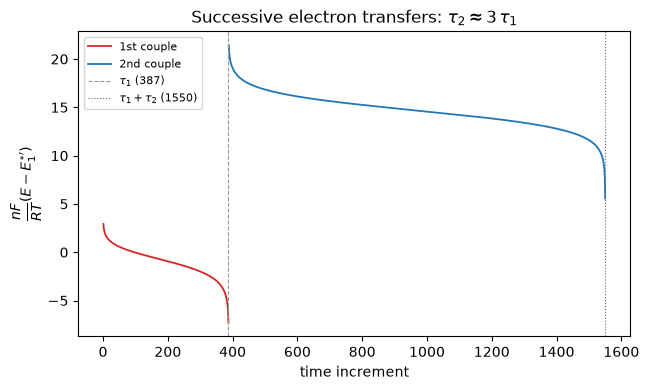

In [9]:
def bv_potential(cO, cR, rhs, alpha=0.5, offset=0.0):
    """Root i/ksDim = cR e^{(1-a)(E+off)} - cO e^{-a(E+off)} for E."""
    def f(E):
        e = E + offset
        return cR * np.exp((1 - alpha) * e) - cO * np.exp(-alpha * e) - rhs
    return brentq(f, -80.0, 80.0, xtol=1e-10)


def two_component_potentials(i=-0.9, n=401, DM=0.35, ks=1.0e6, D=1.0e-5,
                             alpha=0.5, dE2=-15.0):
    """Return (steps, potentials) for the two-component transient."""
    m = grid_size(n, DM)
    iDim = i_dim_from_current(i, n, DM)
    ksDim = ks * np.sqrt(1.0 / (D * DM * (n - 1)))
    rhs = i / ksDim
    O1, R1 = np.ones(m), np.zeros(m)
    O2, R2 = np.ones(m), np.zeros(m)
    pots = []

    for _ in range(n - 1):
        O1, R1, O2, R2 = diffuse(O1, DM), diffuse(R1, DM), diffuse(O2, DM), diffuse(R2, DM)
        O1[0] = (iDim + 4.0 * O1[1] - O1[2]) / 3.0
        R1[0] = (-iDim + 4.0 * R1[1] - R1[2]) / 3.0
        O2[0], R2[0] = 1.0, 0.0
        for arr, bulk in ((O1, 1.0), (R1, 0.0), (O2, 1.0), (R2, 0.0)):
            arr[-1] = bulk
        if O1[0] < 0.0:
            break
        pots.append(bv_potential(O1[0], R1[0], rhs, alpha))   # couple 1
    O1[0], R1[0] = 0.0, 1.0

    for _ in range(4 * (n - 1)):
        O1, R1, O2, R2 = diffuse(O1, DM), diffuse(R1, DM), diffuse(O2, DM), diffuse(R2, DM)
        O1[0], R1[0] = 0.0, 1.0
        O2[0] = (iDim + 4.0 * O1[1] - O1[2] + 4.0 * O2[1] - O2[2]) / 3.0
        R2[0] = (-iDim - 3.0 + 4.0 * R1[1] - R1[2] + 4.0 * R2[1] - R2[2]) / 3.0
        for arr, bulk in ((O1, 1.0), (R1, 0.0), (O2, 1.0), (R2, 0.0)):
            arr[-1] = bulk
        if O2[0] < 0.0:
            break
        pots.append(bv_potential(O2[0], R2[0], rhs, alpha, offset=dE2))  # couple 2
    return np.arange(1, len(pots) + 1), np.array(pots)


steps_ee, pots_ee = two_component_potentials(-0.9, n=n)

fig, ax = plt.subplots(figsize=(6.6, 4))
ax.plot(steps_ee[:n1c], pots_ee[:n1c], color="tab:red", lw=1.3, label="1st couple")
ax.plot(steps_ee[n1c:], pots_ee[n1c:], color="tab:blue", lw=1.3, label="2nd couple")
ax.axvline(n1c, color="0.6", ls="--", lw=0.8, label=fr"$\tau_1$ ({n1c})")
ax.axvline(n1c + n2c, color="0.4", ls=":", lw=0.8, label=fr"$\tau_1+\tau_2$ ({n1c+n2c})")
ax.set_xlabel("time increment")
ax.set_ylabel(r"$\dfrac{nF}{RT}(E-E^{\circ\prime}_1)$")
ax.set_title(r"Successive electron transfers: $\tau_2\approx 3\,\tau_1$")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 6. Summary

Two galvanostatic chronopotentiometry experiments share one explicit FD diffusion
engine and one current-controlled flux boundary, differing only in how many
species are tracked and how the surface current is partitioned:

* **Current reversal.** Reversing the current at $\tau_1$ gives a second
  transition at $\tau_2=\tau_1/3$. The FD ratio matches the analytic $1/3$ to
  within the grid step.
* **Successive electron transfers / two-component.** A well-separated second
  couple produces a second transition at $\tau_2=3\tau_1$ for equal $c$ and $n$.
  The FD ratio approaches $3$ and **converges** toward it under grid refinement;
  removing the second couple collapses the run back to the single Sand
  transition (reduction-to-known-limit check).

Both transition-time ratios were also confirmed **symbolically** with sympy,
independent of the floating-point simulation. These ratios are kinetics- and
current-independent, which is exactly why they are robust diagnostics and why
they make the strongest validation targets for the simulator.

<!-- nav-footer -->

---

[← Chapter 9 — Chronopotentiometry](../09_chronopotentiometry.ipynb)

[Contents (README)](../../README.md)